# Analysis of the feature importance of the baseline models - stratified by groups


Analyze the importance of the features in the baseline models to try to explain the models.
Use this information to improve the features of the models.

In [1]:
import core.constants as c
from core.feature_importance import (
    load_trained_models_and_results,
    load_dataset,
    compute_feature_importances_for_models,
    plot_feature_importances_by_model,
    plot_feature_vs_target_grid,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
results, trained_models = load_trained_models_and_results(c.RICKD_BASELINE_RESULTS_SUMMARY_V2)

In [3]:
X_train, X_test, y_train, y_test = load_dataset(
    c.RICKD_BASELINE_X_TRAIN_FILE,
    c.RICKD_BASELINE_X_TEST_FILE,
    c.RICKD_BASELINE_Y_TRAIN_FILE,
    c.RICKD_BASELINE_Y_TEST_FILE,
)

In [4]:
all_feature_importance = compute_feature_importances_for_models(
    trained_models, X_test, y_test, random_state=RANDOM_STATE
)

Extracting feature importance for Logistic Regression...
Using coef_ for Logistic Regression...
Extracting feature importance for Random Forest...
Using feature_importances_ for Random Forest...
Extracting feature importance for XGBoost...
Using feature_importances_ for XGBoost...
Extracting feature importance for SVM...
Computing permutation importance for SVM...


## Feature Importance Visualization

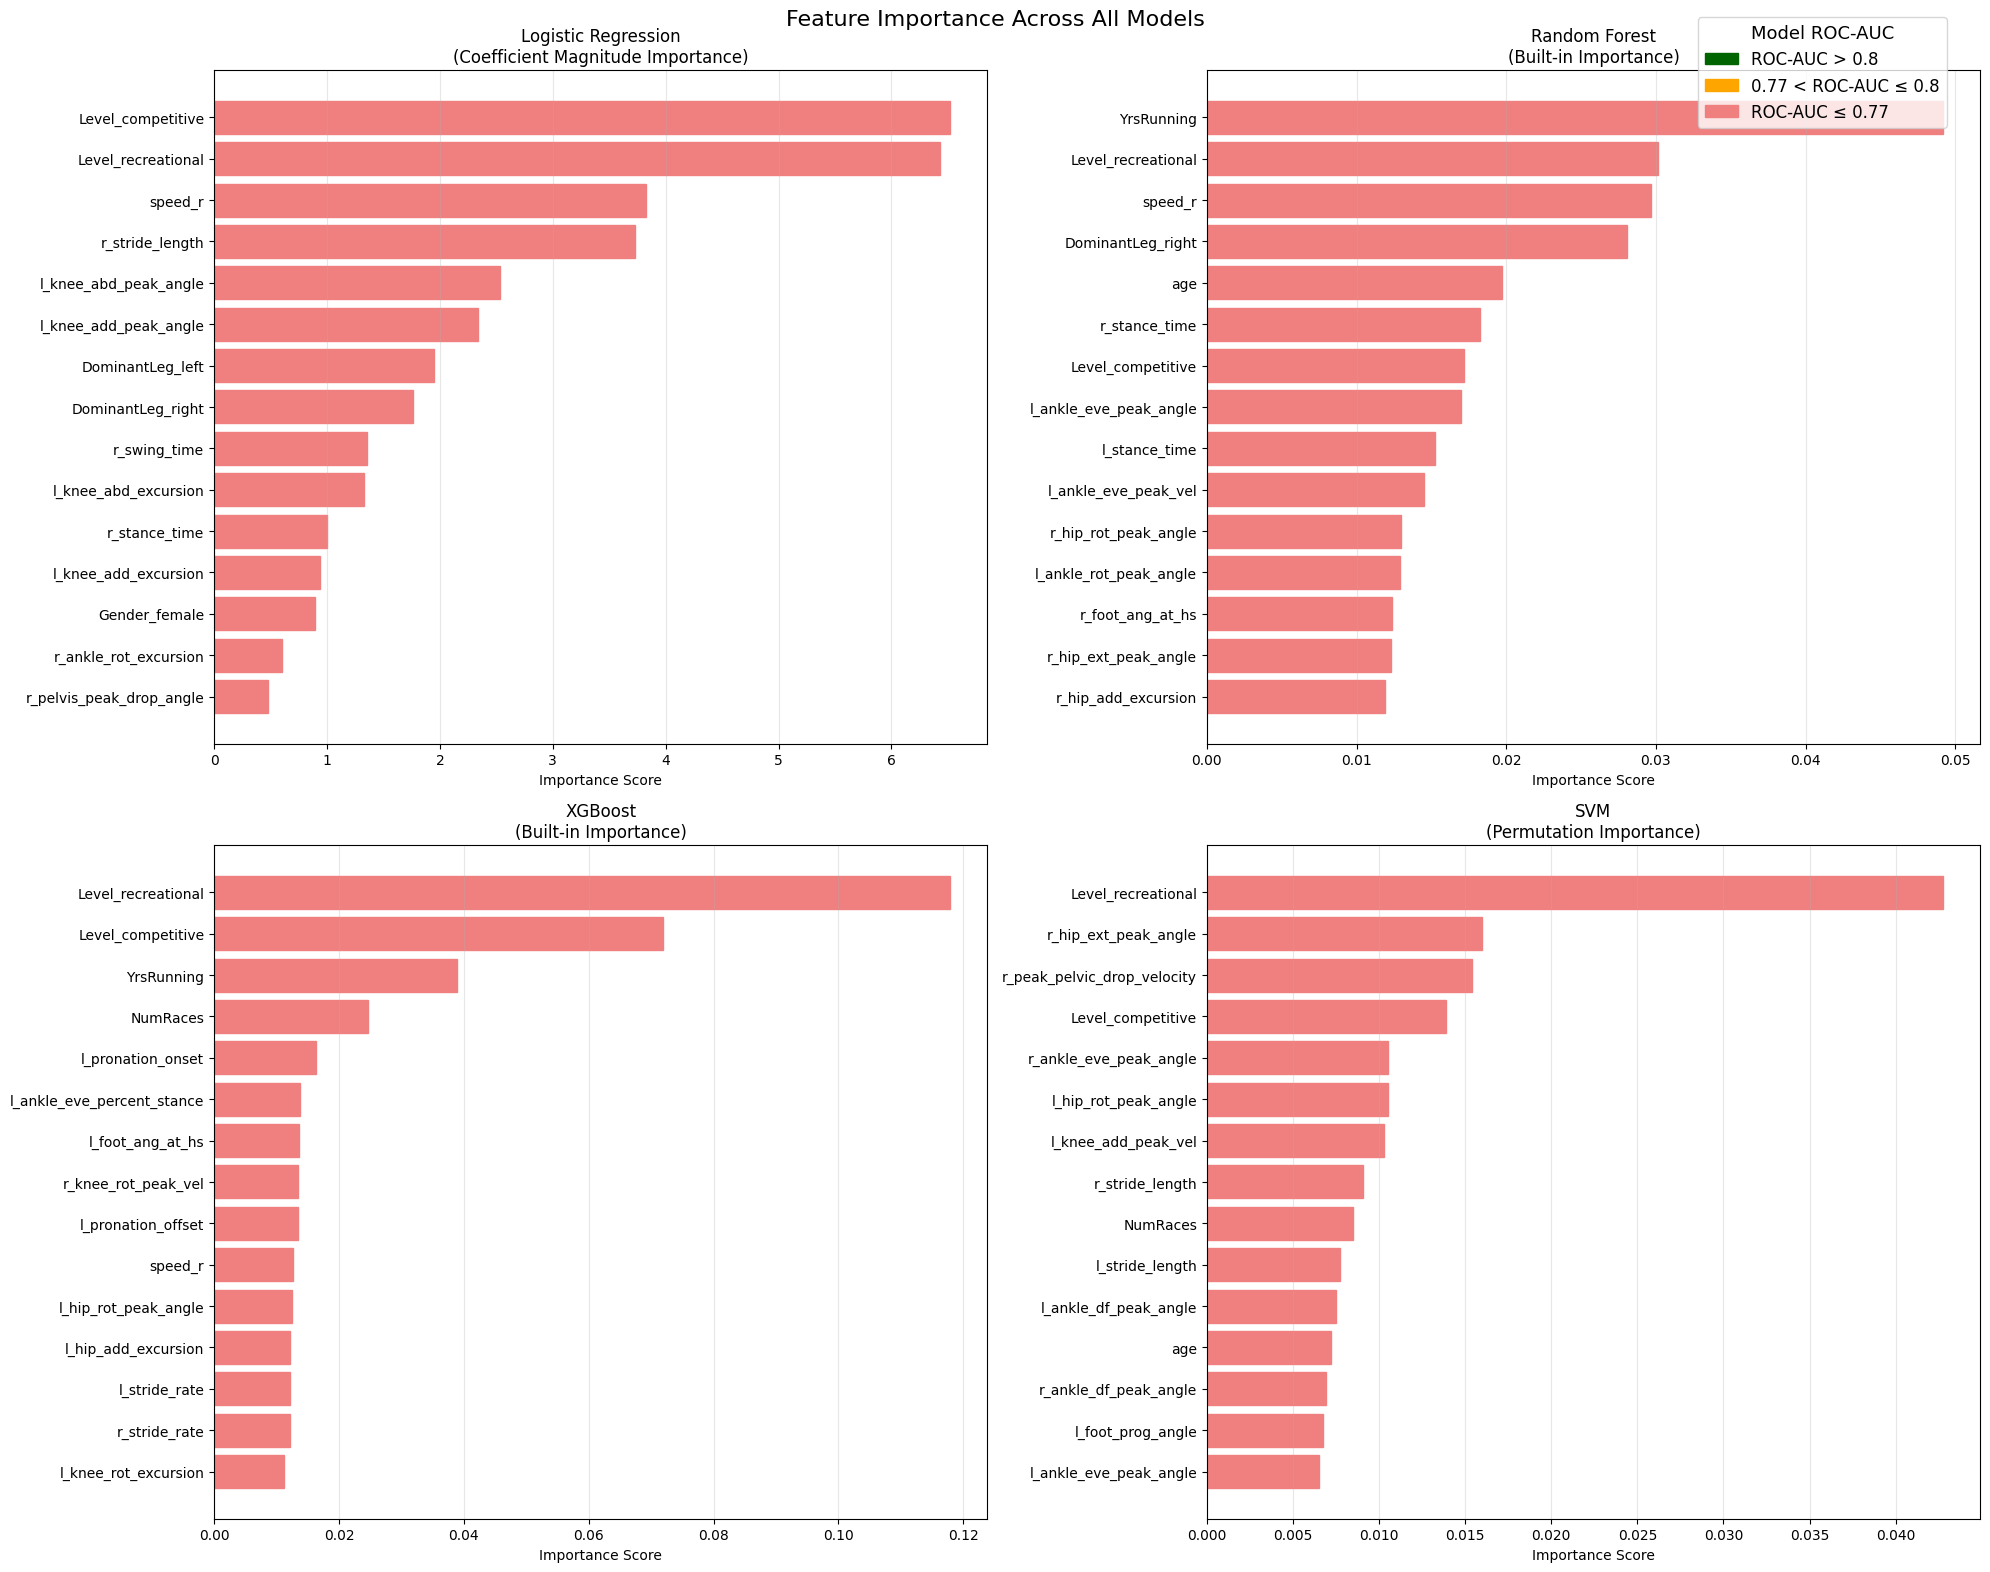

In [5]:
plot_feature_importances_by_model(all_feature_importance, results, top_n=15, figsize=(20, 16))

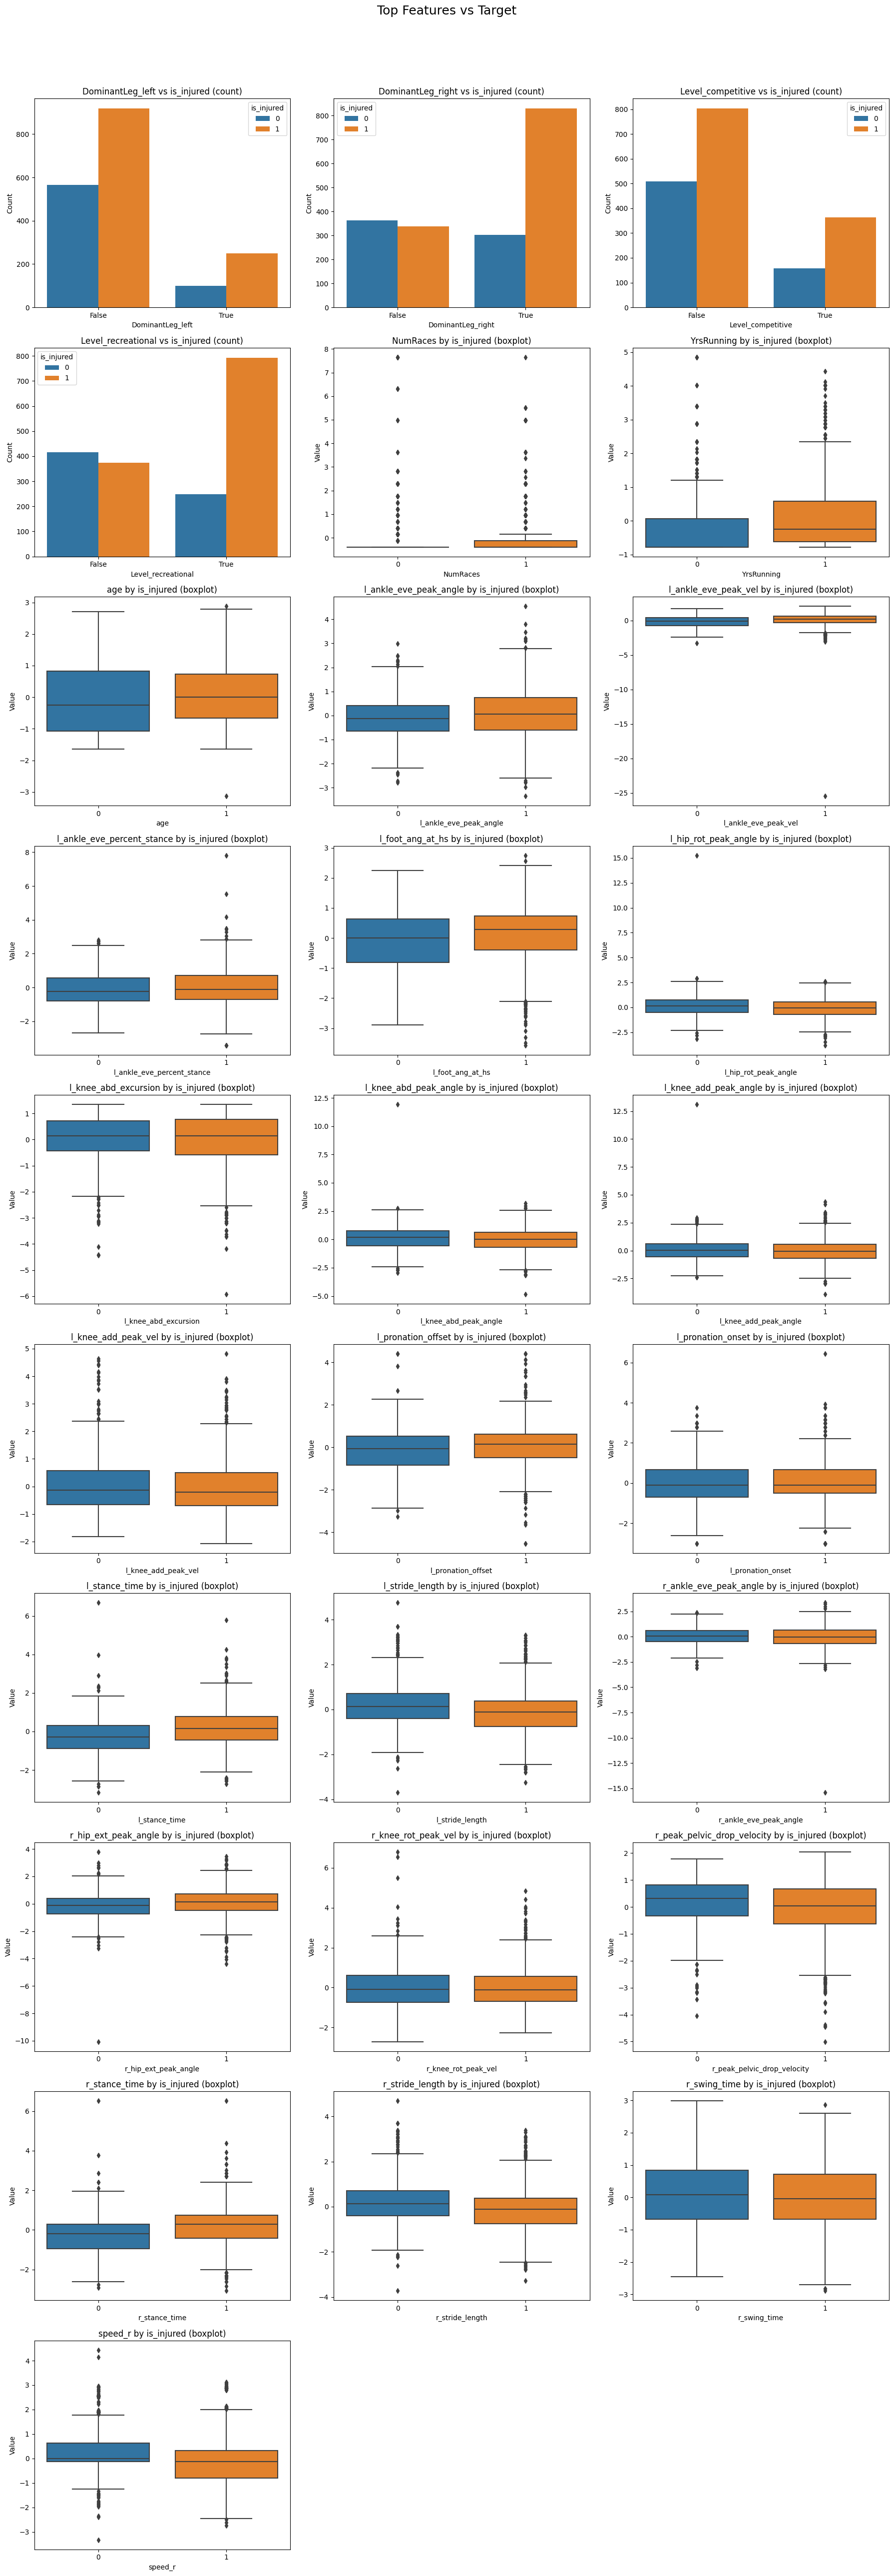

In [6]:
X = pd.read_csv(c.RICKD_BASELINE_X_FILE, index_col=0)
y = pd.read_csv(c.RICKD_BASELINE_Y_FILE, index_col=0)


# Collect top 10 features for each model based on importance
top_features_to_check = set()
for model_name, importance_df in all_feature_importance.items():
    top_features = importance_df.sort_values("importance", ascending=False).head(10)["feature"]
    top_features_to_check.update(top_features)

top_features_to_check = list(top_features_to_check)
top_features_to_check.sort()

plot_feature_vs_target_grid(
    X=X,
    y=y,
    features=top_features_to_check,
    target_col='is_injured',
    n_cols=3,
    figsize_per_cell=(6, 5),
)

In [7]:
from sklearn.linear_model import LassoCV
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import linkage, fcluster

import numpy as np
import pandas as pd

def proxy_r2(X: pd.DataFrame, j: str) -> float:
    X_rest = X.drop(columns=[j])
    model = LassoCV(cv=5, n_alphas=100, random_state=0).fit(X_rest, X[j])
    return model.score(X_rest, X[j])  # R^2; closer to 1 → stronger proxy

def residualize_feature(X: pd.DataFrame, j: str) -> pd.Series:
    X_rest = X.drop(columns=[j])
    model = LassoCV(cv=5, n_alphas=100, random_state=0).fit(X_rest, X[j])
    residual = X[j] - model.predict(X_rest)
    return pd.Series(residual, index=X.index)

def conditional_permute_feature(X: pd.DataFrame, j: str, n_neighbors=30, random_state=0):
    rng = np.random.default_rng(random_state)
    X_perm = X.copy()
    X_rest = X.drop(columns=[j]).to_numpy()
    nbrs = NearestNeighbors(n_neighbors=min(n_neighbors, len(X))).fit(X_rest)
    _, idx = nbrs.kneighbors(X_rest)

    xj = X[j].to_numpy().copy()
    xj_cond = xj.copy()
    for i, neigh in enumerate(idx):
        pool = xj[neigh]
        xj_cond[i] = rng.choice(pool)
    X_perm[j] = xj_cond
    return X_perm

def correlate_and_cluster(X: pd.DataFrame, thresh=0.7):
    corr = X.corr().abs().fillna(0.0)
    dist = np.sqrt(1 - corr)  # in [0,1]
    Z = linkage(dist, method='average')
    labels = fcluster(Z, t=1-np.square(thresh), criterion='distance')
    clusters = {}
    for col, lab in zip(X.columns, labels):
        clusters.setdefault(lab, []).append(col)
    return clusters  # dict: cluster_id -> [features]



Best model: XGBoost (ROC-AUC=0.755)
Base AUC on X_test: 0.7551


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.01930925857605814, tolerance: 0.018798620689655172
  model = cd_fast.enet_coordinate_descent_gram(
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ 

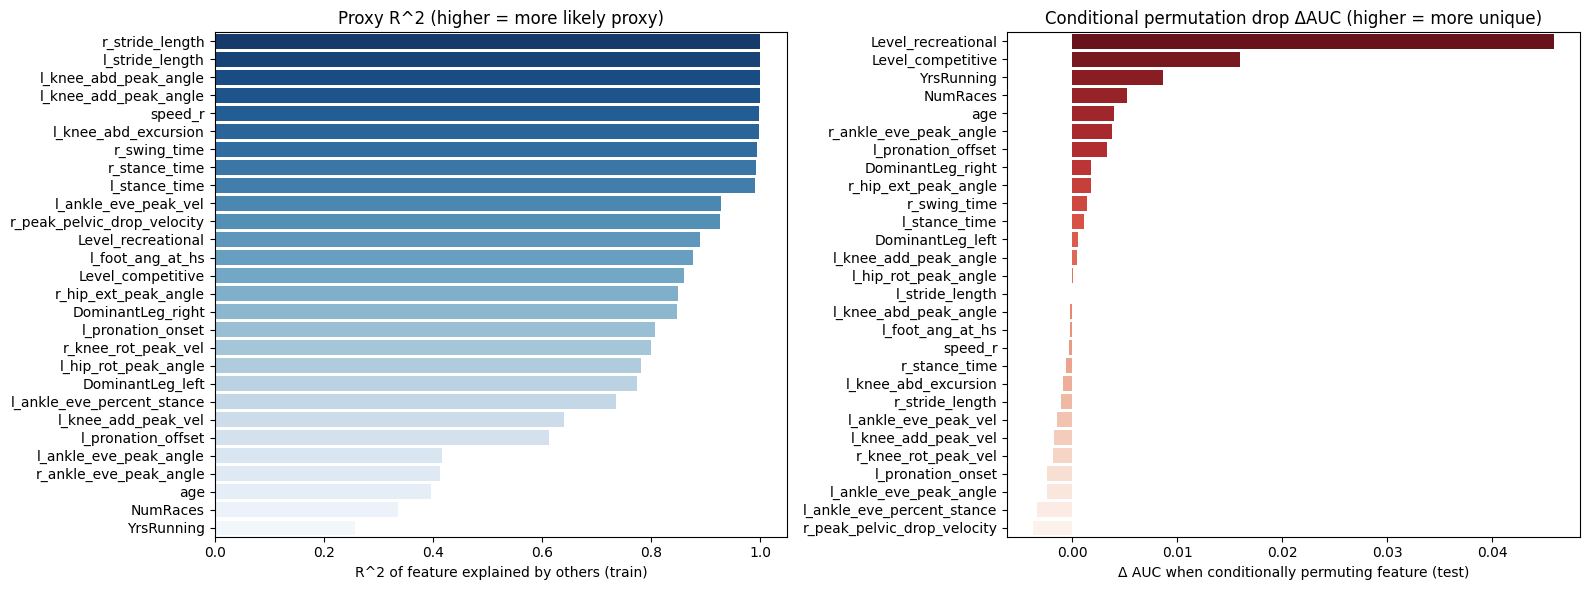

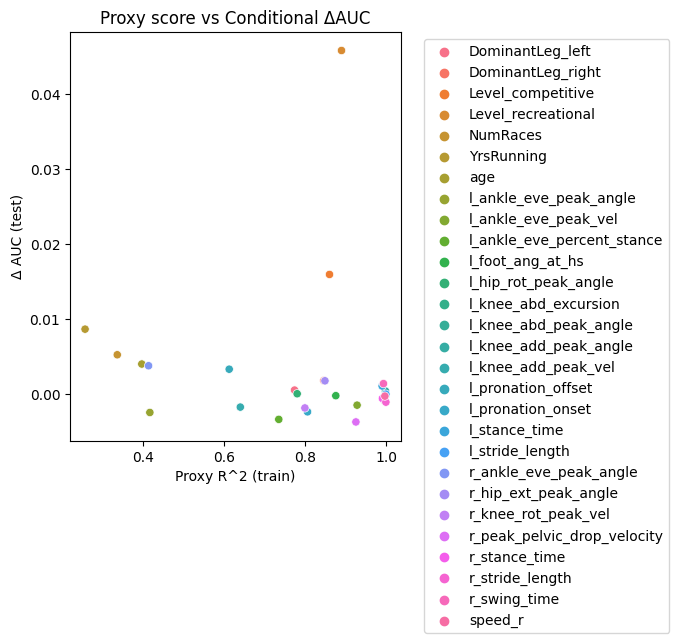

Feature clusters (>=0.7 corr threshold):
 - Cluster 2 (3): ['l_stride_length', 'r_stride_length', 'speed_r']
 - Cluster 1 (2): ['l_stance_time', 'r_stance_time']
 - Cluster 23 (1): ['DominantLeg_left']
 - Cluster 24 (1): ['DominantLeg_right']
 - Cluster 20 (1): ['Level_competitive']
 - Cluster 21 (1): ['Level_recreational']
 - Cluster 22 (1): ['NumRaces']
 - Cluster 25 (1): ['YrsRunning']
 - Cluster 18 (1): ['age']
 - Cluster 11 (1): ['l_ankle_eve_peak_angle']
 - Cluster 14 (1): ['l_ankle_eve_peak_vel']
 - Cluster 3 (1): ['l_ankle_eve_percent_stance']
 - Cluster 15 (1): ['l_foot_ang_at_hs']
 - Cluster 13 (1): ['l_hip_rot_peak_angle']
 - Cluster 8 (1): ['l_knee_abd_excursion']
 - Cluster 6 (1): ['l_knee_abd_peak_angle']
 - Cluster 7 (1): ['l_knee_add_peak_angle']
 - Cluster 17 (1): ['l_knee_add_peak_vel']
 - Cluster 5 (1): ['l_pronation_offset']
 - Cluster 4 (1): ['l_pronation_onset']
 - Cluster 12 (1): ['r_ankle_eve_peak_angle']
 - Cluster 19 (1): ['r_hip_ext_peak_angle']
 - Cluster 16

/var/folders/2w/vl1bz9zs2c37dzy7d38b9cbm0000gn/T/ipykernel_37733/4004817251.py:37: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(dist, method='average')


,feature,proxy_r2,delta_auc
0,Level_recreational,0.890014,4.586207e-02
1,Level_competitive,0.860360,1.597701e-02
2,YrsRunning,0.256554,8.678161e-03
3,NumRaces,0.336112,5.258621e-03
4,age,0.396669,4.022989e-03
5,r_ankle_eve_peak_angle,0.413380,3.793103e-03
6,l_pronation_offset,0.612566,3.333333e-03
7,DominantLeg_right,0.846381,1.810345e-03
8,r_hip_ext_peak_angle,0.849101,1.781609e-03
9,r_swing_time,0.993678,1.408046e-03


In [9]:
# Evaluate proxy vs predictor for top features
from sklearn.metrics import roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# Choose best model by ROC-AUC
best_model_name = max(results, key=lambda k: results[k]["test_roc_auc"]) if len(results) else None
best_model = trained_models[best_model_name] if best_model_name else None
print(f"Best model: {best_model_name} (ROC-AUC={results[best_model_name]['test_roc_auc']:.3f})")

# Helper to get continuous scores for AUC
def _scores(model, X_df):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_df)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X_df)
    # Fallback to predictions (not ideal for AUC, but keeps flow)
    return model.predict(X_df)

# Base AUC on test set
base_scores = _scores(best_model, X_test)
base_auc = roc_auc_score(y_test, base_scores)
print(f"Base AUC on X_test: {base_auc:.4f}")

# Compute proxy R^2 on train features to avoid leakage
proxy_rows = []
condperm_rows = []

features_in_scope = [f for f in top_features_to_check if f in X_test.columns]

for feat in features_in_scope:
    # Proxy score (how well others explain this feature)
    try:
        r2 = proxy_r2(X_train, feat)
    except Exception as e:
        r2 = np.nan
        print(f"proxy_r2 failed for {feat}: {e}")
    proxy_rows.append({"feature": feat, "proxy_r2": r2})

    # Conditional permutation drop on test set
    try:
        X_perm = conditional_permute_feature(X_test, feat, n_neighbors=30, random_state=RANDOM_STATE)
        perm_scores = _scores(best_model, X_perm)
        auc_perm = roc_auc_score(y_test, perm_scores)
        delta_auc = base_auc - auc_perm
    except Exception as e:
        delta_auc = np.nan
        print(f"conditional_permute failed for {feat}: {e}")
    condperm_rows.append({"feature": feat, "delta_auc": delta_auc})

proxy_df = pd.DataFrame(proxy_rows).sort_values("proxy_r2", ascending=False)
condperm_df = pd.DataFrame(condperm_rows).sort_values("delta_auc", ascending=False)

summary_df = proxy_df.merge(condperm_df, on="feature", how="outer")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=proxy_df, y="feature", x="proxy_r2", ax=axes[0], order=proxy_df.sort_values("proxy_r2", ascending=False)["feature"].tolist(), palette="Blues_r")
axes[0].set_title("Proxy R^2 (higher = more likely proxy)")
axes[0].set_xlabel("R^2 of feature explained by others (train)")
axes[0].set_ylabel("")

sns.barplot(data=condperm_df, y="feature", x="delta_auc", ax=axes[1], order=condperm_df.sort_values("delta_auc", ascending=False)["feature"].tolist(), palette="Reds_r")
axes[1].set_title("Conditional permutation drop ΔAUC (higher = more unique)")
axes[1].set_xlabel("Δ AUC when conditionally permuting feature (test)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

# Scatter to relate proxy vs conditional importance
plt.figure(figsize=(7, 6))
sns.scatterplot(data=summary_df, x="proxy_r2", y="delta_auc", hue="feature")
plt.title("Proxy score vs Conditional ΔAUC")
plt.xlabel("Proxy R^2 (train)")
plt.ylabel("Δ AUC (test)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)
plt.tight_layout()
plt.show()

# # Correlation clustermap for top features
# subset_cols = [f for f in features_in_scope if f in X.columns]
# if len(subset_cols) >= 2:
#     corr = X[subset_cols].corr()
#     sns.clustermap(corr, cmap="vlag", center=0, figsize=(10, 10))
#     plt.suptitle("Correlation clustermap (top features)")
#     plt.show()

# Print clusters at |r| >= 0.7 threshold
try:
    clusters = correlate_and_cluster(X[subset_cols], thresh=0.7)
    clusters_sorted = sorted(clusters.items(), key=lambda kv: -len(kv[1]))
    print("Feature clusters (>=0.7 corr threshold):")
    for cid, feats in clusters_sorted:
        print(f" - Cluster {cid} ({len(feats)}): {feats}")
except Exception as e:
    print(f"Clustering failed: {e}")

summary_df.sort_values(["delta_auc"], ascending=False).reset_index(drop=True)
